# Deploying Iris-detection model using Vertex AI


## Overview

In this tutorial, you build a scikit-learn model and deploy it on Vertex AI using the custom container method. You use the FastAPI Python web server framework to create a prediction endpoint. You also incorporate a preprocessor from training pipeline into your online serving application.

Learn more about [Custom training](https://cloud.google.com/vertex-ai/docs/training/custom-training) and [Vertex AI Prediction](https://cloud.google.com/vertex-ai/docs/predictions/get-predictions).

### Dataset

This tutorial uses R.A. Fisher's Iris dataset, a small and popular dataset for machine learning experiments. Each instance has four numerical features, which are different measurements of a flower, and a target label that
categorizes the flower into: **Iris setosa**, **Iris versicolour** and **Iris virginica**.

This tutorial uses [a version of the Iris dataset available in the
scikit-learn library](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_iris.html#sklearn.datasets.load_iris).

### Costs

This tutorial uses billable components of Google Cloud:

* Vertex AI
* Cloud Storage
* Artifact Registry
* Cloud Build

Learn about [Vertex AI
pricing](https://cloud.google.com/vertex-ai/pricing), [Cloud Storage
pricing](https://cloud.google.com/storage/pricing), [Artifact Registry pricing](https://cloud.google.com/artifact-registry/pricing) and [Cloud Build pricing](https://cloud.google.com/build/pricing) and use the [Pricing
Calculator](https://cloud.google.com/products/calculator/)
to generate a cost estimate based on your projected usage.

## Get started

### Install Vertex AI SDK for Python and other required packages



In [ ]:

# Vertex SDK for Python
! pip3 install --upgrade --quiet  google-cloud-aiplatform

In [ ]:
# Install required packages
!pip install --upgrade --quiet scikit-learn pandas numpy google-cloud-storage matplotlib seaborn

### Import the required libraries

In [9]:
# Import libraries
import pandas as pd
import numpy as np
import os
import json
import joblib
import time
from datetime import datetime, timezone
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from google.cloud import storage
import mlflow
from mlflow import MlflowClient
import mlflow.sklearn
import warnings
from pprint import pprint
warnings.filterwarnings('ignore')

### Set Google Cloud project information
Learn more about [setting up a project and a development environment](https://cloud.google.com/vertex-ai/docs/start/cloud-environment).

In [26]:
PROJECT_ID = "rapid-sphinx-473108-u4" 
LOCATION = "us-central1" 
BUCKET_NAME = "mlops-course-rapid-sphinx-473108-u4-rkm-w8"
BUCKET_URI = f"gs://mlops-course-rapid-sphinx-473108-u4-rkm-w8"
DATA_DIR = "data"
MODEL_ARTIFACT_DIR = "models"

### Create a Cloud Storage bucket

Create a storage bucket to store intermediate artifacts such as datasets.

**If your bucket doesn't already exist**: Run the following cell to create your Cloud Storage bucket.

In [4]:
! gsutil mb -l {LOCATION} -p {PROJECT_ID} {BUCKET_URI}

Creating gs://mlops-course-rapid-sphinx-473108-u4-rkm-w8/...
ServiceException: 409 A Cloud Storage bucket named 'mlops-course-rapid-sphinx-473108-u4-rkm-w8' already exists. Try another name. Bucket names must be globally unique across all Google Cloud projects, including those outside of your organization.


### Initialize Vertex AI SDK for Python

To get started using Vertex AI, you must have an existing Google Cloud project and [enable the Vertex AI API](https://console.cloud.google.com/flows/enableapi?apiid=aiplatform.googleapis.com).

In [5]:
from google.cloud import aiplatform

aiplatform.init(project=PROJECT_ID, location=LOCATION, staging_bucket=BUCKET_URI)

In [6]:
# Upload data to GCS
!gsutil cp data/iris.csv {BUCKET_URI}/{DATA_DIR}/

Copying file://data/iris.csv [Content-Type=text/csv]...
/ [1 files][  3.8 KiB/  3.8 KiB]                                                
Operation completed over 1 objects/3.8 KiB.                                      


### MLFlow Client Setup

In [10]:
# MLFLOW CLIENT SETUP
mlflow.set_tracking_uri("http://127.0.0.1:8100")
client = MlflowClient(mlflow.get_tracking_uri())
all_experiments = client.search_experiments()
pprint(all_experiments)

[<Experiment: artifact_location='mlflow-artifacts:/443368084953637015', creation_time=1763214313595, experiment_id='443368084953637015', last_update_time=1763214313595, lifecycle_stage='active', name='iris-data-poisoning-analysis', tags={}>,
 <Experiment: artifact_location='mlflow-artifacts:/936475633867133609', creation_time=1760995976146, experiment_id='936475633867133609', last_update_time=1760995976146, lifecycle_stage='active', name='IRIS Classifier W5 GA', tags={'mlflow.experimentKind': 'custom_model_development'}>,
 <Experiment: artifact_location='mlflow-artifacts:/907837742909285039', creation_time=1760963153092, experiment_id='907837742909285039', last_update_time=1760963153092, lifecycle_stage='active', name='IRIS Classifier', tags={'mlflow.experimentKind': 'custom_model_development'}>,
 <Experiment: artifact_location='mlflow-artifacts:/0', creation_time=1760954255533, experiment_id='0', last_update_time=1760954255533, lifecycle_stage='active', name='Default', tags={}>]


In [11]:
mlflow.get_tracking_uri()

'http://127.0.0.1:8100'

In [12]:
# experiment_name = "IRIS Classifier"
experiment_name = "iris-data-poisoning-analysis"
mlflow.set_experiment(experiment_name)

<Experiment: artifact_location='mlflow-artifacts:/443368084953637015', creation_time=1763214313595, experiment_id='443368084953637015', last_update_time=1763214313595, lifecycle_stage='active', name='iris-data-poisoning-analysis', tags={}>

In [13]:
exp = client.get_experiment_by_name(experiment_name)
print("Experiment info:")
pprint(exp)

Experiment info:
<Experiment: artifact_location='mlflow-artifacts:/443368084953637015', creation_time=1763214313595, experiment_id='443368084953637015', last_update_time=1763214313595, lifecycle_stage='active', name='iris-data-poisoning-analysis', tags={}>


### Data Preparation

In [23]:
from google.cloud import storage

def upload_blob(bucket_name, source_file_name, destination_blob_name):
    """
    Upload a file to Google Cloud Storage bucket
    
    Parameters:
    - bucket_name: Name of the GCS bucket (e.g., 'mlops-course-rapid-sphinx-473108-u4-rkm-w1')
    - source_file_name: Local file path to upload (e.g., 'artifacts/baseline_model.pkl')
    - destination_blob_name: Destination path in GCS bucket (e.g., 'my-models/iris-poisoning-week5/baseline_model.pkl')
    """
    # Create a storage client
    client = storage.Client()
    
    # Get the bucket
    bucket = client.bucket(bucket_name)
    
    # Create a blob object from the filepath
    blob = bucket.blob(destination_blob_name)
    
    # Upload the file to GCS
    blob.upload_from_filename(source_file_name)
    
    print(f"✓ Uploaded {source_file_name} to gs://{bucket_name}/{destination_blob_name}")

# # Example usage:
# bucket_name = "mlops-course-rapid-sphinx-473108-u4-rkm-w1"
# baseline_model_path = "artifacts/baseline_model.pkl"
# MODEL_ARTIFACT_DIR = "my-models/iris-poisoning-week5"

# upload_blob(
#     bucket_name, 
#     baseline_model_path, 
#     f"{MODEL_ARTIFACT_DIR}/baseline_model.pkl"
# )


In [15]:
# Load Data
data = pd.read_csv('data/iris.csv')
data.head(5)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [17]:
print(f"Original dataset shape: {data.shape}")
print(f"\nClass distribution:\n{data['species'].value_counts()}")

Original dataset shape: (150, 5)

Class distribution:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


In [18]:
# Function to poison data with random noise
def poison_data(X, y, poison_percentage, poison_type='random_noise'):
    """
    Poison the dataset by injecting random noise
    
    Parameters:
    - X: Features (numpy array or dataframe)
    - y: Labels (numpy array or series)
    - poison_percentage: Percentage of data to poison (0-100)
    - poison_type: Type of poisoning ('random_noise', 'label_flip')
    
    Returns:
    - X_poisoned: Poisoned features
    - y_poisoned: Poisoned labels
    - poisoned_indices: Indices of poisoned samples
    """
    X_poisoned = X.copy()
    y_poisoned = y.copy()
    
    n_samples = len(X)
    n_poison = int(n_samples * poison_percentage / 100)
    
    # Randomly select samples to poison
    poisoned_indices = np.random.choice(n_samples, size=n_poison, replace=False)
    
    if poison_type == 'random_noise':
        # Add random Gaussian noise to features
        for idx in poisoned_indices:
            # Generate random noise with mean=0 and std proportional to feature range
            noise = np.random.normal(0, 2, size=X_poisoned.shape[1])
            X_poisoned[idx] = X_poisoned[idx] + noise
    
    elif poison_type == 'label_flip':
        # Flip labels to random incorrect classes
        unique_labels = np.unique(y)
        for idx in poisoned_indices:
            current_label = y_poisoned[idx]
            # Select a different label randomly
            other_labels = [label for label in unique_labels if label != current_label]
            y_poisoned[idx] = np.random.choice(other_labels)
    
    print(f"Poisoned {n_poison} samples ({poison_percentage}%) using {poison_type}")
    return X_poisoned, y_poisoned, poisoned_indices


In [20]:
# Prepare features and labels
X = data.drop('species', axis=1).values
y = data['species'].values

# Encode labels
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Split original data
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"\nOriginal train set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")


Original train set size: 120
Test set size: 30


In [21]:
# Create artifacts directory
os.makedirs("artifacts", exist_ok=True)

In [22]:
# Dictionary to store results
results = []
baseline_metrics = {}

In [27]:
# STEP 1: Train and Save Baseline Model (Clean Data - No Poisoning)
# ============================================================================
print("\n" + "="*20)
print("TRAINING BASELINE MODEL ON CLEAN DATA")
print("="*20)

with mlflow.start_run(run_name="baseline_clean_model"):
    
    # Log parameters
    mlflow.log_param("poison_level", 0)
    mlflow.log_param("poison_type", "none")
    mlflow.log_param("model_type", "DecisionTreeClassifier")
    mlflow.log_param("test_size", 0.2)
    mlflow.log_param("random_state", 42)
    mlflow.log_param("max_depth", 5)
    mlflow.log_param("num_poisoned_samples", 0)
    mlflow.log_param("is_baseline", True)
    
    # Train baseline model
    baseline_model = DecisionTreeClassifier(random_state=42, max_depth=5)
    train_start = time.time()
    baseline_model.fit(X_train, y_train)
    train_time = time.time() - train_start
    
    mlflow.log_metric("training_time_seconds", train_time)
    
    # Predictions on training set
    y_train_pred = baseline_model.predict(X_train)
    train_accuracy = accuracy_score(y_train, y_train_pred)
    train_precision = precision_score(y_train, y_train_pred, average='weighted')
    train_recall = recall_score(y_train, y_train_pred, average='weighted')
    train_f1 = f1_score(y_train, y_train_pred, average='weighted')
    
    # Predictions on test set
    y_test_pred = baseline_model.predict(X_test)
    test_accuracy = accuracy_score(y_test, y_test_pred)
    test_precision = precision_score(y_test, y_test_pred, average='weighted')
    test_recall = recall_score(y_test, y_test_pred, average='weighted')
    test_f1 = f1_score(y_test, y_test_pred, average='weighted')
    
    # Store baseline metrics for comparison
    baseline_metrics = {
        'train_accuracy': train_accuracy,
        'test_accuracy': test_accuracy,
        'test_precision': test_precision,
        'test_recall': test_recall,
        'test_f1': test_f1
    }
    
    # Log metrics
    mlflow.log_metric("train_accuracy", train_accuracy)
    mlflow.log_metric("train_precision", train_precision)
    mlflow.log_metric("train_recall", train_recall)
    mlflow.log_metric("train_f1_score", train_f1)
    
    mlflow.log_metric("test_accuracy", test_accuracy)
    mlflow.log_metric("test_precision", test_precision)
    mlflow.log_metric("test_recall", test_recall)
    mlflow.log_metric("test_f1_score", test_f1)
    
    # Log model to MLFlow
    mlflow.sklearn.log_model(baseline_model, "model")
    
    # Save model locally using joblib
    baseline_model_path = "artifacts/baseline_model.pkl"
    joblib.dump(baseline_model, baseline_model_path)
    mlflow.log_artifact(baseline_model_path)
    print(f"✓ Baseline model saved to {baseline_model_path}")
    
    # Save label encoder
    le_path = "artifacts/label_encoder.pkl"
    joblib.dump(le, le_path)
    mlflow.log_artifact(le_path)
    print(f"✓ Label encoder saved to {le_path}")
    
    # Save classification report
    report = classification_report(y_test, y_test_pred, 
                                   target_names=le.classes_,
                                   output_dict=True)
    
    report_path = "artifacts/baseline_classification_report.json"
    with open(report_path, 'w') as f:
        json.dump(report, f, indent=4)
    mlflow.log_artifact(report_path)
    
    # Save confusion matrix
    cm = confusion_matrix(y_test, y_test_pred)
    cm_path = "artifacts/baseline_confusion_matrix.txt"
    np.savetxt(cm_path, cm, fmt='%d')
    mlflow.log_artifact(cm_path)
    
    # Save baseline metadata
    baseline_metadata = {
        'model_name': 'baseline_iris_classifier',
        'training_date': datetime.now(timezone.utc).isoformat(),
        'train_samples': len(X_train),
        'test_samples': len(X_test),
        'features': data.drop('species', axis=1).columns.tolist(),
        'classes': le.classes_.tolist(),
        'metrics': baseline_metrics
    }
    
    metadata_path = "artifacts/baseline_model_metadata.json"
    with open(metadata_path, 'w') as f:
        json.dump(baseline_metadata, f, indent=4)
    mlflow.log_artifact(metadata_path)
    
    # Upload baseline model to GCS
    upload_blob(BUCKET_NAME, baseline_model_path, f"{MODEL_ARTIFACT_DIR}/baseline_model.pkl")
    upload_blob(BUCKET_NAME, le_path, f"{MODEL_ARTIFACT_DIR}/label_encoder.pkl")
    upload_blob(BUCKET_NAME, metadata_path, f"{MODEL_ARTIFACT_DIR}/baseline_model_metadata.json")
    
    # Store baseline results
    results.append({
        'poison_type': 'none',
        'poison_level': 0,
        'train_accuracy': train_accuracy,
        'test_accuracy': test_accuracy,
        'test_precision': test_precision,
        'test_recall': test_recall,
        'test_f1': test_f1,
        'training_time': train_time,
        'num_poisoned': 0
    })
    
    print(f"\n✓ BASELINE MODEL RESULTS:")
    print(f"  Train Accuracy: {train_accuracy:.4f}")
    print(f"  Test Accuracy: {test_accuracy:.4f}")
    print(f"  Test Precision: {test_precision:.4f}")
    print(f"  Test Recall: {test_recall:.4f}")
    print(f"  Test F1-Score: {test_f1:.4f}")
    print(f"  Training Time: {train_time:.4f}s")


2025/11/15 14:17:19 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



TRAINING BASELINE MODEL ON CLEAN DATA


2025/11/15 14:17:22 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


✓ Baseline model saved to artifacts/baseline_model.pkl
✓ Label encoder saved to artifacts/label_encoder.pkl
✓ Uploaded artifacts/baseline_model.pkl to gs://mlops-course-rapid-sphinx-473108-u4-rkm-w8/models/baseline_model.pkl
✓ Uploaded artifacts/label_encoder.pkl to gs://mlops-course-rapid-sphinx-473108-u4-rkm-w8/models/label_encoder.pkl
✓ Uploaded artifacts/baseline_model_metadata.json to gs://mlops-course-rapid-sphinx-473108-u4-rkm-w8/models/baseline_model_metadata.json

✓ BASELINE MODEL RESULTS:
  Train Accuracy: 1.0000
  Test Accuracy: 0.9333
  Test Precision: 0.9333
  Test Recall: 0.9333
  Test F1-Score: 0.9333
  Training Time: 0.0035s
🏃 View run baseline_clean_model at: http://127.0.0.1:8100/#/experiments/443368084953637015/runs/5e06198af3fc4bf18834eed3a8061a90
🧪 View experiment at: http://127.0.0.1:8100/#/experiments/443368084953637015


In [28]:
# STEP 2: Train Models with Data Poisoning at Various Levels
# ============================================================================

# Define poisoning levels to test (excluding 0% as we already trained it)
poison_levels = [5, 10, 50]
poison_types = ['random_noise', 'label_flip']

# Train models with different poisoning levels
for poison_type in poison_types:
    for poison_level in poison_levels:
        
        run_name = f"poison_{poison_type}_{poison_level}pct"
        print(f"\n{'='*80}")
        print(f"Training model with {poison_level}% {poison_type} poisoning")
        print(f"{'='*80}")
        
        # Start MLFlow run
        with mlflow.start_run(run_name=run_name):
            
            # Log parameters
            mlflow.log_param("poison_level", poison_level)
            mlflow.log_param("poison_type", poison_type)
            mlflow.log_param("model_type", "DecisionTreeClassifier")
            mlflow.log_param("test_size", 0.2)
            mlflow.log_param("random_state", 42)
            mlflow.log_param("max_depth", 5)
            mlflow.log_param("is_baseline", False)
            
            # Poison training data
            X_train_poisoned, y_train_poisoned, poisoned_indices = poison_data(
                X_train, y_train, poison_level, poison_type=poison_type
            )
            mlflow.log_param("num_poisoned_samples", len(poisoned_indices))
            
            # Train model
            model = DecisionTreeClassifier(random_state=42, max_depth=5)
            train_start = time.time()
            model.fit(X_train_poisoned, y_train_poisoned)
            train_time = time.time() - train_start
            
            mlflow.log_metric("training_time_seconds", train_time)
            
            # Predictions on training set
            y_train_pred = model.predict(X_train_poisoned)
            train_accuracy = accuracy_score(y_train_poisoned, y_train_pred)
            train_precision = precision_score(y_train_poisoned, y_train_pred, average='weighted')
            train_recall = recall_score(y_train_poisoned, y_train_pred, average='weighted')
            train_f1 = f1_score(y_train_poisoned, y_train_pred, average='weighted')
            
            # Predictions on test set (clean data)
            y_test_pred = model.predict(X_test)
            test_accuracy = accuracy_score(y_test, y_test_pred)
            test_precision = precision_score(y_test, y_test_pred, average='weighted')
            test_recall = recall_score(y_test, y_test_pred, average='weighted')
            test_f1 = f1_score(y_test, y_test_pred, average='weighted')
            
            # Log metrics
            mlflow.log_metric("train_accuracy", train_accuracy)
            mlflow.log_metric("train_precision", train_precision)
            mlflow.log_metric("train_recall", train_recall)
            mlflow.log_metric("train_f1_score", train_f1)
            
            mlflow.log_metric("test_accuracy", test_accuracy)
            mlflow.log_metric("test_precision", test_precision)
            mlflow.log_metric("test_recall", test_recall)
            mlflow.log_metric("test_f1_score", test_f1)
            
            # Calculate performance degradation from baseline
            accuracy_drop = baseline_metrics['test_accuracy'] - test_accuracy
            accuracy_drop_pct = (accuracy_drop / baseline_metrics['test_accuracy']) * 100
            mlflow.log_metric("accuracy_degradation", accuracy_drop)
            mlflow.log_metric("accuracy_degradation_pct", accuracy_drop_pct)
            
            # Log model to MLFlow
            mlflow.sklearn.log_model(model, "model")
            
            # Save model locally
            model_path = f"artifacts/model_{run_name}.pkl"
            joblib.dump(model, model_path)
            mlflow.log_artifact(model_path)
            print(f"✓ Model saved to {model_path}")
            
            # Save classification report
            report = classification_report(y_test, y_test_pred, 
                                         target_names=le.classes_,
                                         output_dict=True)
            
            report_path = f"artifacts/classification_report_{run_name}.json"
            with open(report_path, 'w') as f:
                json.dump(report, f, indent=4)
            mlflow.log_artifact(report_path)
            
            # Save confusion matrix
            cm = confusion_matrix(y_test, y_test_pred)
            cm_path = f"artifacts/confusion_matrix_{run_name}.txt"
            np.savetxt(cm_path, cm, fmt='%d')
            mlflow.log_artifact(cm_path)
            
            # Save poisoned data indices for analysis
            poisoned_indices_path = f"artifacts/poisoned_indices_{run_name}.npy"
            np.save(poisoned_indices_path, poisoned_indices)
            mlflow.log_artifact(poisoned_indices_path)
            
            # Upload model to GCS
            upload_blob(BUCKET_NAME, model_path, f"{MODEL_ARTIFACT_DIR}/{run_name}.pkl")
            
            # Store results
            results.append({
                'poison_type': poison_type,
                'poison_level': poison_level,
                'train_accuracy': train_accuracy,
                'test_accuracy': test_accuracy,
                'test_precision': test_precision,
                'test_recall': test_recall,
                'test_f1': test_f1,
                'training_time': train_time,
                'num_poisoned': len(poisoned_indices),
                'accuracy_degradation': accuracy_drop,
                'accuracy_degradation_pct': accuracy_drop_pct
            })
            
            print(f"\n✓ Results for {run_name}:")
            print(f"  Train Accuracy: {train_accuracy:.4f}")
            print(f"  Test Accuracy: {test_accuracy:.4f}")
            print(f"  Test Precision: {test_precision:.4f}")
            print(f"  Test Recall: {test_recall:.4f}")
            print(f"  Test F1-Score: {test_f1:.4f}")
            print(f"  Training Time: {train_time:.4f}s")
            print(f"  Accuracy Drop: {accuracy_drop:.4f} ({accuracy_drop_pct:.2f}%)")




Training model with 5% random_noise poisoning
Poisoned 6 samples (5%) using random_noise


2025/11/15 14:21:04 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/11/15 14:21:08 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


✓ Model saved to artifacts/model_poison_random_noise_5pct.pkl
✓ Uploaded artifacts/model_poison_random_noise_5pct.pkl to gs://mlops-course-rapid-sphinx-473108-u4-rkm-w8/models/poison_random_noise_5pct.pkl

✓ Results for poison_random_noise_5pct:
  Train Accuracy: 1.0000
  Test Accuracy: 0.9333
  Test Precision: 0.9333
  Test Recall: 0.9333
  Test F1-Score: 0.9333
  Training Time: 0.0027s
  Accuracy Drop: 0.0000 (0.00%)
🏃 View run poison_random_noise_5pct at: http://127.0.0.1:8100/#/experiments/443368084953637015/runs/c04764c4a2a546f3915e4c2301a21ea9
🧪 View experiment at: http://127.0.0.1:8100/#/experiments/443368084953637015

Training model with 10% random_noise poisoning


2025/11/15 14:21:09 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Poisoned 12 samples (10%) using random_noise


...

✓ Model saved to artifacts/model_poison_label_flip_5pct.pkl
✓ Uploaded artifacts/model_poison_label_flip_5pct.pkl to gs://mlops-course-rapid-sphinx-473108-u4-rkm-w8/models/poison_label_flip_5pct.pkl

✓ Results for poison_label_flip_5pct:
  Train Accuracy: 0.9833
  Test Accuracy: 0.8333
  Test Precision: 0.8426
  Test Recall: 0.8333
  Test F1-Score: 0.8341
  Training Time: 0.0014s
  Accuracy Drop: 0.1000 (10.71%)
🏃 View run poison_label_flip_5pct at: http://127.0.0.1:8100/#/experiments/443368084953637015/runs/5caef317da3a4650b6af9ef0fc2cda2b
🧪 View experiment at: http://127.0.0.1:8100/#/experiments/443368084953637015

Training model with 10% label_flip poisoning
Poisoned 12 samples (10%) using label_flip


2025/11/15 14:21:19 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/11/15 14:21:21 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


✓ Model saved to artifacts/model_poison_label_flip_10pct.pkl
✓ Uploaded artifacts/model_poison_label_flip_10pct.pkl to gs://mlops-course-rapid-sphinx-473108-u4-rkm-w8/models/poison_label_flip_10pct.pkl

✓ Results for poison_label_flip_10pct:
  Train Accuracy: 0.9250
  Test Accuracy: 0.9333
  Test Precision: 0.9394
  Test Recall: 0.9333
  Test F1-Score: 0.9312
  Training Time: 0.0027s
  Accuracy Drop: 0.0000 (0.00%)
🏃 View run poison_label_flip_10pct at: http://127.0.0.1:8100/#/experiments/443368084953637015/runs/da87534ac3b94042a9cff3d3d9ef891d
🧪 View experiment at: http://127.0.0.1:8100/#/experiments/443368084953637015

Training model with 50% label_flip poisoning
Poisoned 60 samples (50%) using label_flip


2025/11/15 14:21:22 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/11/15 14:21:25 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


✓ Model saved to artifacts/model_poison_label_flip_50pct.pkl
✓ Uploaded artifacts/model_poison_label_flip_50pct.pkl to gs://mlops-course-rapid-sphinx-473108-u4-rkm-w8/models/poison_label_flip_50pct.pkl

✓ Results for poison_label_flip_50pct:
  Train Accuracy: 0.7417
  Test Accuracy: 0.6000
  Test Precision: 0.5500
  Test Recall: 0.6000
  Test F1-Score: 0.5527
  Training Time: 0.0015s
  Accuracy Drop: 0.3333 (35.71%)
🏃 View run poison_label_flip_50pct at: http://127.0.0.1:8100/#/experiments/443368084953637015/runs/ce3447a01523431db0307bbda0f88acc
🧪 View experiment at: http://127.0.0.1:8100/#/experiments/443368084953637015


In [34]:
# STEP 3: Generate Summary and Comparison Reports
# ============================================================================

# Create summary DataFrame
results_df = pd.DataFrame(results)
print("\n" + "="*80)
print("SUMMARY OF ALL EXPERIMENTS")
print("="*80)
print(results_df.to_string(index=False))

# Save results to CSV
results_csv_path = "artifacts/poisoning_experiment_results.csv"
results_df.to_csv(results_csv_path, index=False)
print(f"\n✓ Results saved to {results_csv_path}")

# Upload results to GCS
upload_blob(BUCKET_NAME, results_csv_path, f"{MODEL_ARTIFACT_DIR}/poisoning_experiment_results.csv")

# Create a comprehensive comparison report
comparison_report = {
    'experiment_date': datetime.now(timezone.utc).isoformat(),
    'baseline_metrics': baseline_metrics,
    'all_results': results,
    'summary': {
        'total_experiments': len(results),
        'poison_types_tested': list(set([r['poison_type'] for r in results])),
        'poison_levels_tested': sorted(list(set([r['poison_level'] for r in results]))),
        'worst_accuracy_drop': max([r.get('accuracy_degradation', 0) for r in results]),
        'best_poisoned_accuracy': max([r['test_accuracy'] for r in results if r['poison_level'] > 0])
    }
}

comparison_path = "artifacts/comprehensive_comparison_report.json"
with open(comparison_path, 'w') as f:
    json.dump(comparison_report, f, indent=4)
print(f"✓ Comprehensive comparison report saved to {comparison_path}")

# Upload comparison report
upload_blob(BUCKET_NAME, comparison_path, f"{MODEL_ARTIFACT_DIR}/comprehensive_comparison_report.json")

print("\n" + "="*80)
print("EXPERIMENT COMPLETE - ALL MODELS SAVED")
print("="*80)
print(f"✓ Baseline model: artifacts/baseline_model.pkl")
print(f"✓ Poisoned models: artifacts/model_poison_*.pkl")
print(f"✓ All artifacts uploaded to: gs://{BUCKET_NAME}/{MODEL_ARTIFACT_DIR}/")
print(f"✓ MLFlow tracking: Check MLFlow UI for detailed experiment tracking")



SUMMARY OF ALL EXPERIMENTS
 poison_type  poison_level  train_accuracy  test_accuracy  test_precision  test_recall  test_f1  training_time  num_poisoned  accuracy_degradation  accuracy_degradation_pct
        none             0        1.000000       0.933333        0.933333     0.933333 0.933333       0.003507             0                   NaN                       NaN
random_noise             5        1.000000       0.933333        0.933333     0.933333 0.933333       0.002714             6              0.000000                  0.000000
random_noise            10        0.983333       0.900000        0.902357     0.900000 0.899749       0.001703            12              0.033333                  3.571429
random_noise            50        0.941667       0.833333        0.849817     0.833333 0.829497       0.002334            60              0.100000                 10.714286
  label_flip             5        0.983333       0.833333        0.842593     0.833333 0.834131       0.001


Visualization saved to artifacts/poisoning_analysis_comprehensive.png
✓ Uploaded artifacts/poisoning_analysis_comprehensive.png to gs://mlops-course-rapid-sphinx-473108-u4-rkm-w8/models/poisoning_analysis_comprehensive.png


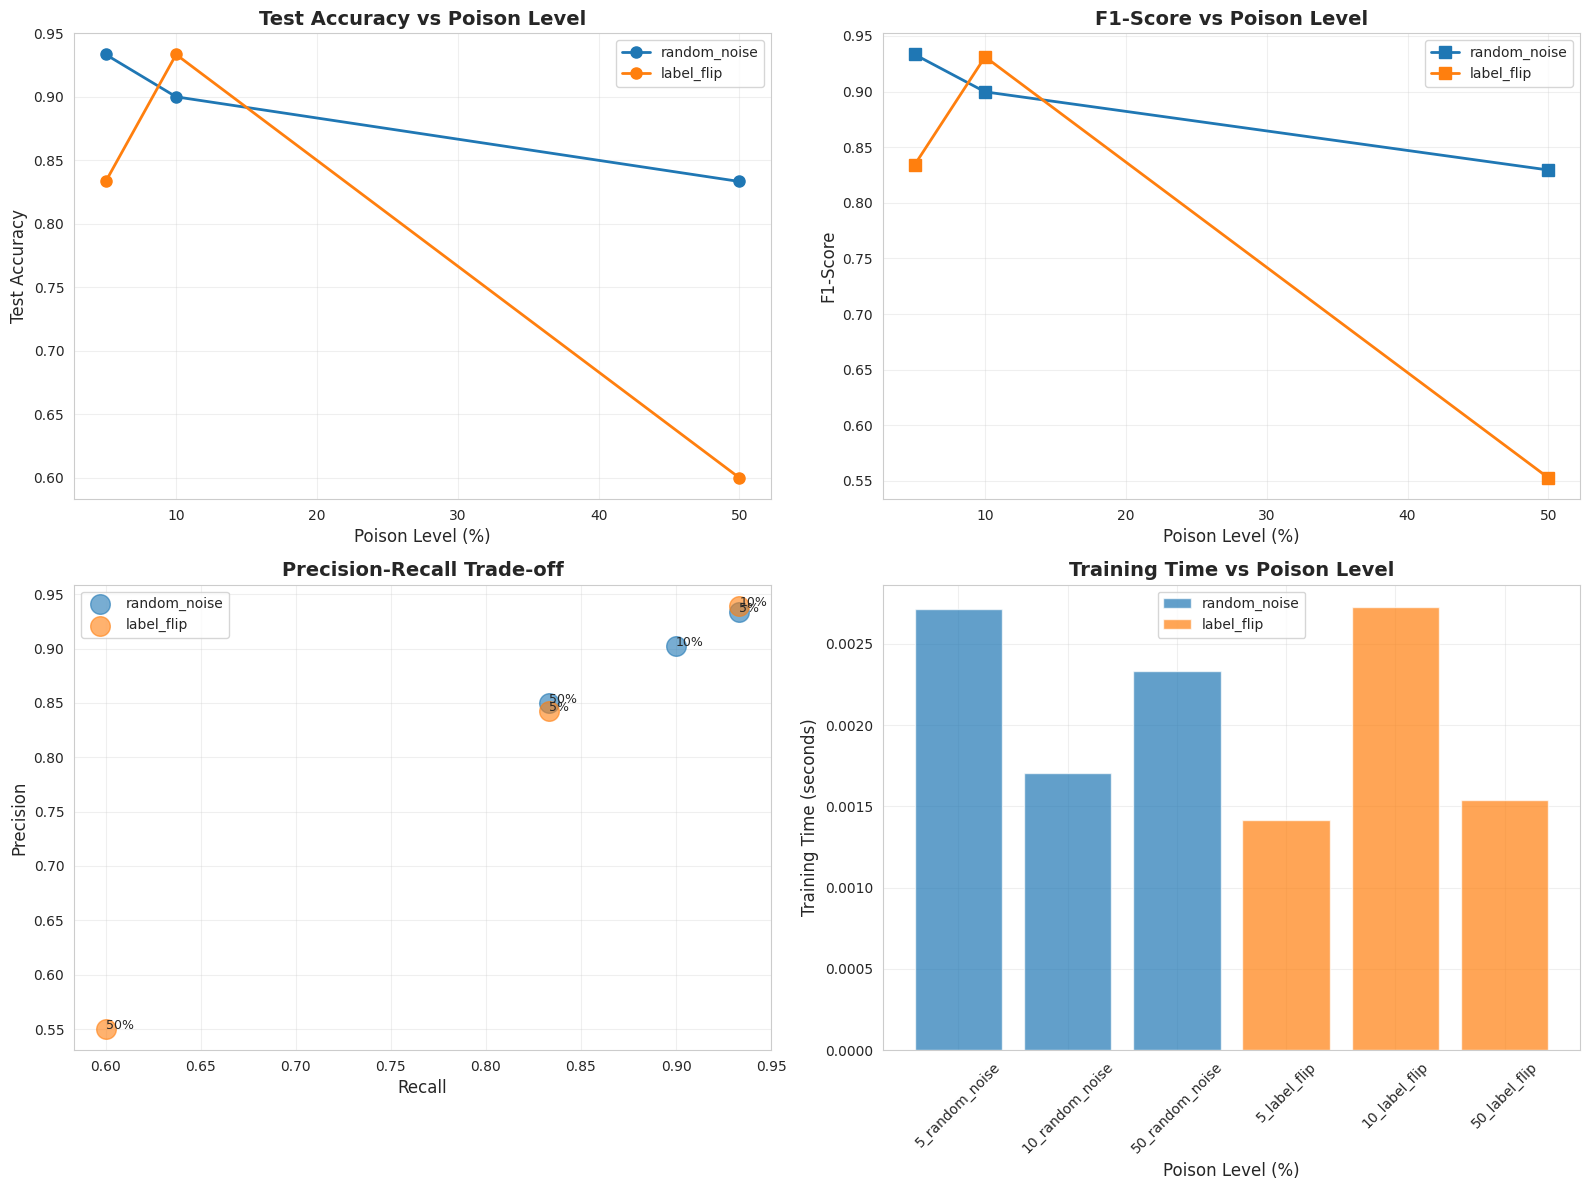

In [35]:
# Visualization and detailed analysis
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 10)

# Create comparison plots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Test Accuracy vs Poison Level for different poison types
for poison_type in poison_types:
    subset = results_df[results_df['poison_type'] == poison_type]
    axes[0, 0].plot(subset['poison_level'], subset['test_accuracy'], 
                    marker='o', linewidth=2, markersize=8, label=poison_type)
axes[0, 0].set_xlabel('Poison Level (%)', fontsize=12)
axes[0, 0].set_ylabel('Test Accuracy', fontsize=12)
axes[0, 0].set_title('Test Accuracy vs Poison Level', fontsize=14, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: F1-Score vs Poison Level
for poison_type in poison_types:
    subset = results_df[results_df['poison_type'] == poison_type]
    axes[0, 1].plot(subset['poison_level'], subset['test_f1'], 
                    marker='s', linewidth=2, markersize=8, label=poison_type)
axes[0, 1].set_xlabel('Poison Level (%)', fontsize=12)
axes[0, 1].set_ylabel('F1-Score', fontsize=12)
axes[0, 1].set_title('F1-Score vs Poison Level', fontsize=14, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Precision vs Recall
for poison_type in poison_types:
    subset = results_df[results_df['poison_type'] == poison_type]
    axes[1, 0].scatter(subset['test_recall'], subset['test_precision'], 
                      s=200, alpha=0.6, label=poison_type)
    for idx, row in subset.iterrows():
        axes[1, 0].annotate(f"{int(row['poison_level'])}%", 
                           (row['test_recall'], row['test_precision']),
                           fontsize=9)
axes[1, 0].set_xlabel('Recall', fontsize=12)
axes[1, 0].set_ylabel('Precision', fontsize=12)
axes[1, 0].set_title('Precision-Recall Trade-off', fontsize=14, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Training Time vs Poison Level
for poison_type in poison_types:
    subset = results_df[results_df['poison_type'] == poison_type]
    axes[1, 1].bar(subset['poison_level'].astype(str) + f'_{poison_type}', 
                   subset['training_time'], alpha=0.7, label=poison_type)
axes[1, 1].set_xlabel('Poison Level (%)', fontsize=12)
axes[1, 1].set_ylabel('Training Time (seconds)', fontsize=12)
axes[1, 1].set_title('Training Time vs Poison Level', fontsize=14, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('artifacts/poisoning_analysis_comprehensive.png', dpi=300, bbox_inches='tight')
print("\nVisualization saved to artifacts/poisoning_analysis_comprehensive.png")

# Upload visualization to GCS
upload_blob(
    BUCKET_NAME,
    "artifacts/poisoning_analysis_comprehensive.png",
    f"{MODEL_ARTIFACT_DIR}/poisoning_analysis_comprehensive.png"
)
